# Revision analyses: Sobol interpretation, speed motivation, viscosity section

Evidence for three revisions to the paper.

**A. Sobol (Sec. 2.6/3.8).** The paper's GSA varies *molecular descriptors* fed to the surrogate. Yet the
paper presents the result as guidance on *AIOMFAC interaction parameters*, which were never varied.
- A1. Re-run the descriptor GSA (seeded) with bootstrap CIs and a convergence check.
- A2. Measure how far the independently sampled descriptor vectors lie from real molecules (out-of-distribution
  check).
- A3. An in-distribution alternative: exact variance decomposition over *real* molecules × w × T, computed
  with AIOMFAC directly, for BIMOG and for atmospheric MCM molecules.
- A4. The analysis the paper's claim actually requires: a Sobol GSA over AIOMFAC's main-group interaction
  parameters a_mn.

**B. Speed (Sec. 1, 2.7, 3.9–3.10).** Measured per-molecule fixed costs, end-to-end screening cost, multicomponent
scaling and equilibrium-solver call counts. These define where a surrogate actually saves time.

**C. Viscosity (Sec. 2.5/3.7).**
- C1. Is "adding Tg" informative, or is it the label's own parameter? This is tested with a Tg-only baseline.
- C2. Measured vs. ML-predicted Tg, and how Tg uncertainty propagates to viscosity.
- C3. A fair comparison with the coefficient model on the same molecules.

Inputs: `bimog_unified.json`, `mcm_v331_species.tsv` (see `mcm_learning_curve.ipynb`). Runtime is about
25–40 min on a CPU.

## 0) Setup

In [1]:
try:
    import aiomfac_py, rdkit, SALib, sklearn  # noqa: F401
    from aiomfac_py.tgml_armeli import predict_tg_ml_smiles  # noqa: F401
    print("dependencies available")
except ImportError:
    from pathlib import Path
    import subprocess
    REPO_DIR = Path("/content") / "aiomfac-python"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)], check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate --smiles")
    subprocess.run(["pip", "install", "-q", "rdkit", "SALib", "scikit-learn", "-e", f"{REPO_DIR}[tgml,tgml-smiles]"], check=True)

dependencies available


In [2]:
import json, time, hashlib, re, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import qmc, spearmanr
from rdkit import Chem, RDLogger
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze

import aiomfac_py as aiomfac
from aiomfac_py import ActivityModel, Component
from aiomfac_py.s2as import smiles_to_components
from aiomfac_py.params import load_subgroup_params
import aiomfac_py.s2as._mapping as _aiomfac_mapping
import aiomfac_py.s2as._smarts as _smarts
from aiomfac_py.tgml_armeli import predict_tg_ml_smiles
from aiomfac_py.viscosity import organic_mixture_viscosity, pure_organic_viscosity_vtf

_aiomfac_mapping.print = lambda *args, **kwargs: None
RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore", category=UserWarning)
sg = load_subgroup_params()
WATER = Component(1, "Water", ((16, 1),))
SEEDS = (0, 1, 2)
print(f"aiomfac_py {aiomfac.__version__} | torch {torch.__version__}")

aiomfac_py 0.0.24 | torch 2.14.1


In [3]:
# ---------- shared helpers (Part I definitions) ----------
def bimog_category(d):
    has_n, has_hal = d["#N"] != 0, d["#Hal"] != 0
    return ("bimog_n_and_hal" if has_n and has_hal else "bimog_n_only" if has_n
            else "bimog_hal_only" if has_hal else "cho")


def featurize(name, smi, category):
    r = smiles_to_components([smi], water_as_component1=True)
    if r.removed:
        return None
    try:
        m = ActivityModel(r.components)
        if not (m.evaluate([0.9, 0.1], 298.15, basis="mass").gamma_neutral > 0).all():
            return None
    except Exception:
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    mol_h = Chem.AddHs(mol)
    sym = [a.GetSymbol() for a in mol_h.GetAtoms()]
    n_c = max(sym.count("C"), 1)
    return {"name": name, "smiles": smi, "category": category, "subgroups": r.components[1].subgroups,
            "molar_mass_g_mol": sum(a.GetMass() for a in mol_h.GetAtoms()), "o_to_c": sym.count("O") / n_c,
            "n_to_c": sym.count("N") / n_c, "n_unmatched": int(r.n_unmatched_atoms[0])}


def is_test_molecule(smiles):
    return int(hashlib.sha256(smiles.encode()).hexdigest(), 16) % 100 < 15


with open("bimog_unified.json") as f:
    bimog_raw = json.load(f)
bimog = [o for d in bimog_raw if (o := featurize(d["name"], d["smiles"], bimog_category(d)))]
tg_measured = {d["name"]: d["tg_K"] for d in bimog_raw}

mcm_raw = pd.read_csv("mcm_v331_species.tsv", sep="\t", comment="*")
mcm = []
for _, row in mcm_raw.iterrows():
    mol = Chem.MolFromSmiles(str(row.Smiles))
    if (mol is None or str(row.Excited).lower() == "true" or any(a.GetNumRadicalElectrons() for a in mol.GetAtoms())
            or not {a.GetSymbol() for a in mol.GetAtoms()} <= {"C", "H", "O", "N"}
            or "C" not in {a.GetSymbol() for a in mol.GetAtoms()} or mol.GetNumHeavyAtoms() < 2):
        continue
    o = featurize(row.Name, str(row.Smiles), "mcm")
    if o and o["n_unmatched"] == 0:
        mcm.append(o)
print(f"BIMOG {len(bimog)} | MCM {len(mcm)}")

# main-group labels, taken from the s2as SMARTS table comments (first subgroup description seen per main group)
_SUB_DESC = {}
for line in open(_smarts.__file__, encoding="utf-8"):
    mt = re.match(r"\s*\[(\d+),\s*'.*?'\],\s*#\*?\s*(.*)", line)
    if mt and int(mt.group(1)) < 300 and int(mt.group(1)) not in _SUB_DESC:
        _SUB_DESC[int(mt.group(1))] = re.sub(r"\s*subgroup.*$", "", mt.group(2)).strip()[:28]
MG_LABEL = {1: "CHn (alkyl)", 7: "H2O"}
for s, dsc in sorted(_SUB_DESC.items()):
    try:
        MG_LABEL.setdefault(sg.main_group(s), dsc)
    except Exception:
        pass
mg_name = lambda g: f"{g}:{MG_LABEL.get(g, '?')}"

BIMOG 368 | MCM 3409


---
## A1) Descriptor-space Sobol GSA, re-run with confidence intervals

Same procedure as Part IV (8 functional-group fractions with the simplex construction, O:C, N:C, log M,
log1p(q), w, T), except that the surrogate is trained with an explicit seed. Sobol indices are computed at
N = 1024 (as in the notebook) and N = 4096 (convergence check), with SALib's bootstrap 95 % CIs.

In [4]:
MAIN_GROUPS_B = sorted({sg.main_group(int(s)) for o in bimog for s, q in o["subgroups"]})
def rich_features(kept, main_groups):
    mg_index = {g: i for i, g in enumerate(main_groups)}
    feat = []
    for o in kept:
        mg, tq = np.zeros(len(main_groups)), 0
        for s, q in o["subgroups"]:
            g = sg.main_group(int(s))
            if g in mg_index:
                mg[mg_index[g]] += q
            tq += q
        feat.append([*(mg / max(tq, 1)), o["o_to_c"], o["n_to_c"], np.log(o["molar_mass_g_mol"]), np.log1p(tq)])
    return np.array(feat, dtype=np.float32)


def build_dataset(kept, seed=0, n_comp=20, n_temp=4):
    rng = np.random.RandomState(seed)
    rows = []
    for oi, o in enumerate(kept):
        m = ActivityModel([WATER, Component(2, "org", tuple(o["subgroups"]))])
        edges = np.linspace(0.02, 0.98, n_comp + 1)
        for w in rng.uniform(edges[:-1], edges[1:]):
            for T in rng.uniform(273.15, 313.15, n_temp):
                try:
                    lg = m.evaluate([w, 1 - w], T, basis="mass").ln_gamma
                    if np.isfinite(lg[:2]).all():
                        rows.append((oi, w, T, lg[0], lg[1]))
                except Exception:
                    pass
    return np.array(rows)


class MLPHead(nn.Module):
    def __init__(self, n_in, n_out=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, n_out))

    def forward(self, x):
        return self.net(x)


def train_mlp(X, Y, fit_idx, seed, max_epochs=500, patience=30):
    '''Part I loop, seeded; validation = first 10 % of fit_idx (fit_idx already shuffled with RandomState(0)).'''
    n_val = int(0.1 * len(fit_idx)); val, fit = fit_idx[:n_val], fit_idx[n_val:]
    x_mean, x_std = X[fit].mean(0), X[fit].std(0)
    x_std = np.where(x_std < 1e-3, 1.0, x_std)
    y_mean, y_std = Y[fit].mean(0), Y[fit].std(0) + 1e-6
    Xf, Yf = torch.tensor((X[fit] - x_mean) / x_std), torch.tensor((Y[fit] - y_mean) / y_std)
    Xv, Yv = torch.tensor((X[val] - x_mean) / x_std), torch.tensor((Y[val] - y_mean) / y_std)
    torch.manual_seed(seed); rng = np.random.RandomState(seed)
    model = MLPHead(X.shape[1], Y.shape[1]); opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss(); best, state, bad = 1e9, None, 0
    for epoch in range(max_epochs):
        model.train()
        perm = torch.from_numpy(rng.permutation(len(fit)))
        for s in range(0, len(fit), 256):
            i = perm[s:s + 256]; opt.zero_grad(); loss_fn(model(Xf[i]), Yf[i]).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = loss_fn(model(Xv), Yv).item()
        if v < best - 1e-5:
            best, state, bad = v, {k: t.clone() for k, t in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(state); model.eval()
    def predict(Xq):
        with torch.no_grad():
            return model(torch.tensor(((Xq - x_mean) / x_std).astype(np.float32))).numpy() * y_std + y_mean
    return predict, model, (x_mean, x_std, y_mean, y_std)


featB = rich_features(bimog, MAIN_GROUPS_B)
dataB = build_dataset(bimog)
oiB = dataB[:, 0].astype(int)
XB = np.concatenate([featB[oiB], np.column_stack([dataB[:, 1], (dataB[:, 2] - 293.15) / 20])], 1).astype(np.float32)
YB = dataB[:, 3:5].astype(np.float32)
testB = np.array([is_test_molecule(o["smiles"]) for o in bimog])
tr_all = np.where(~testB[oiB])[0]
perm0 = np.random.RandomState(0).permutation(len(tr_all))
fitB = tr_all[perm0[int(0.2 * len(tr_all)):]]
surrogate, sur_model, sur_norm = train_mlp(XB, YB, fitB, seed=0)
gen_err = np.abs(surrogate(XB[testB[oiB]]) - YB[testB[oiB]]).mean(0)
print(f"surrogate trained; held-out MAE water={gen_err[0]:.3f} organic={gen_err[1]:.3f}")

surrogate trained; held-out MAE water=0.022 organic=0.288


In [5]:
FUNC_GROUPS = {3: "frac_aromatic_ACH", 69: "frac_hydroxyl_OH", 52: "frac_polyol_CH", 20: "frac_carboxylic_COOH",
               13: "frac_ether_CH2O", 9: "frac_ketone_CH2CO", 11: "frac_ester_CCOO", 15: "frac_amine_CNH"}
nmg = len(MAIN_GROUPS_B)
raw_caps = {}
for g in FUNC_GROUPS:
    col = featB[:, MAIN_GROUPS_B.index(g)]; nz = col[col > 0]
    raw_caps[g] = min(float(np.percentile(nz, 95)), 0.5) if len(nz) else 0.1
caps = {g: v * 0.9 / sum(raw_caps.values()) for g, v in raw_caps.items()}
names = list(FUNC_GROUPS.values()) + ["o_to_c", "n_to_c", "log_molar_mass", "log1p_total_q", "wtf_water", "T_norm"]
pct = lambda j, q: float(np.percentile(featB[:, nmg + j], q))
bounds = ([[0.0, caps[g]] for g in FUNC_GROUPS] + [[0.0, pct(0, 95)], [0.0, pct(1, 95)], [pct(2, 5), pct(2, 95)],
          [pct(3, 5), pct(3, 95)], [0.02, 0.98], [(263.15 - 293.15) / 20, (313.15 - 293.15) / 20]])
problem = {"num_vars": len(names), "names": names, "bounds": bounds}


def to_features(X_sa):
    Xm = np.zeros((len(X_sa), XB.shape[1]), np.float32)
    for k, g in enumerate(FUNC_GROUPS):
        Xm[:, MAIN_GROUPS_B.index(g)] = X_sa[:, k]
    Xm[:, MAIN_GROUPS_B.index(1)] = 1 - X_sa[:, :len(FUNC_GROUPS)].sum(1)
    Xm[:, nmg:nmg + 6] = X_sa[:, len(FUNC_GROUPS):]
    return Xm


gsa_rows = {}
for N in (1024, 4096):
    X_sa = sobol_sample.sample(problem, N, calc_second_order=False, seed=0)
    pred = surrogate(to_features(X_sa))
    for k, out in enumerate(["ln_gamma_water", "ln_gamma_organic"]):
        Si = sobol_analyze.analyze(problem, pred[:, k].astype(float), calc_second_order=False, seed=0)
        for i, nm in enumerate(names):
            gsa_rows[(out, nm, N)] = (Si["S1"][i], Si["S1_conf"][i], Si["ST"][i], Si["ST_conf"][i])
    if N == 1024:
        X_sa_1024 = X_sa
gsa = pd.DataFrame(gsa_rows, index=["S1", "S1_conf", "ST", "ST_conf"]).T
gsa.index.names = ["output", "factor", "N"]
tab = gsa.xs(4096, level="N")
tab = tab.assign(ST_fmt=tab.ST.round(3).astype(str) + " ± " + tab.ST_conf.round(3).astype(str),
                 S1_fmt=tab.S1.round(3).astype(str) + " ± " + tab.S1_conf.round(3).astype(str))
for out in ["ln_gamma_water", "ln_gamma_organic"]:
    t = tab.loc[out].sort_values("ST", ascending=False)[["ST_fmt", "S1_fmt"]]
    t["ST (N=1024)"] = gsa.xs((out, 1024), level=("output", "N")).loc[t.index, "ST"].round(3)
    print(f"\n{out}: descriptor Sobol indices, N=4096 (± 95% bootstrap CI)")
    display(t)
gsa.to_csv("sobol_descriptor_indices.csv")


ln_gamma_water: descriptor Sobol indices, N=4096 (± 95% bootstrap CI)


,ST_fmt,S1_fmt,ST (N=1024)
factor,,,
wtf_water,0.748 ± 0.1,0.051 ± 0.064,0.946
log1p_total_q,0.307 ± 0.057,0.067 ± 0.026,0.327
o_to_c,0.278 ± 0.046,0.044 ± 0.018,0.327
frac_carboxylic_COOH,0.225 ± 0.034,0.047 ± 0.023,0.253
log_molar_mass,0.07 ± 0.011,0.013 ± 0.011,0.073
frac_hydroxyl_OH,0.049 ± 0.007,0.017 ± 0.01,0.048
frac_ether_CH2O,0.035 ± 0.006,0.013 ± 0.006,0.036
frac_ketone_CH2CO,0.022 ± 0.006,-0.001 ± 0.006,0.026
frac_ester_CCOO,0.02 ± 0.003,-0.0 ± 0.006,0.020



ln_gamma_organic: descriptor Sobol indices, N=4096 (± 95% bootstrap CI)


,ST_fmt,S1_fmt,ST (N=1024)
factor,,,
wtf_water,0.689 ± 0.052,0.488 ± 0.037,0.763
log1p_total_q,0.207 ± 0.018,0.063 ± 0.02,0.206
o_to_c,0.12 ± 0.011,0.056 ± 0.015,0.127
frac_carboxylic_COOH,0.086 ± 0.008,0.041 ± 0.012,0.090
frac_hydroxyl_OH,0.042 ± 0.004,0.035 ± 0.008,0.045
frac_ketone_CH2CO,0.024 ± 0.002,0.011 ± 0.008,0.024
frac_ether_CH2O,0.022 ± 0.002,0.012 ± 0.007,0.023
frac_polyol_CH,0.02 ± 0.002,0.007 ± 0.007,0.021
log_molar_mass,0.02 ± 0.002,0.008 ± 0.006,0.020


## A2) How realistic are the sampled descriptor vectors?

For each Saltelli sample, we compute the distance (in standardized molecular-descriptor space) to the nearest
*training* molecule. We compare it with the same distance for the *real* held-out BIMOG molecules, which is
the regime in which the surrogate's test error (about 0.3 ln units) was measured.

NN distance to training molecules: real held-out molecules median 0.82 (95th pct 3.70); Sobol samples median 3.22
Sobol samples farther than the 95th percentile of real held-out molecules: 18%


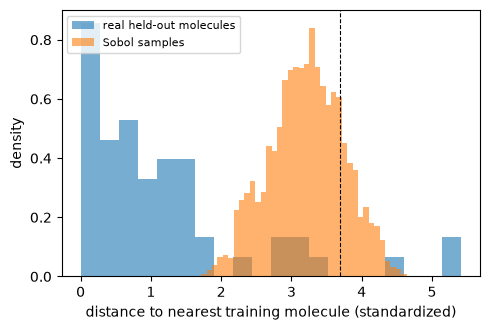

In [6]:
mol_cols = slice(0, nmg + 4)
F_train = featB[~testB][:, mol_cols]
mu, sd = F_train.mean(0), F_train.std(0); sd = np.where(sd < 1e-6, 1, sd)
def nn_dist(F):
    Z, Zt = (F - mu) / sd, (F_train - mu) / sd
    return np.array([np.min(np.linalg.norm(Zt - z, axis=1)) for z in Z])
d_real = nn_dist(featB[testB][:, mol_cols])
d_sobol = nn_dist(to_features(X_sa_1024[:4000])[:, mol_cols])
thr = np.percentile(d_real, 95)
print(f"NN distance to training molecules: real held-out molecules median {np.median(d_real):.2f} "
      f"(95th pct {thr:.2f}); Sobol samples median {np.median(d_sobol):.2f}")
print(f"Sobol samples farther than the 95th percentile of real held-out molecules: {100*(d_sobol > thr).mean():.0f}%")

# internal consistency: oxygen implied by OH + COOH fractions vs the independently sampled O:C
plt.figure(figsize=(5, 3.4))
plt.hist(d_real, bins=20, density=True, alpha=0.6, label="real held-out molecules")
plt.hist(d_sobol, bins=40, density=True, alpha=0.6, label="Sobol samples")
plt.axvline(thr, color="k", lw=0.8, ls="--")
plt.xlabel("distance to nearest training molecule (standardized)"); plt.ylabel("density"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("sobol_ood_check.png", dpi=200); plt.show()

## A3) In-distribution alternative: exact variance decomposition over real molecules

Y(m, w, T) is evaluated with AIOMFAC directly on a full factorial grid (every molecule × 10 w × 5 T). On a full
grid, the main-effect indices are exact ANOVA quantities: S_mol = Var_m(E[Y|m]) / Var(Y), and likewise for
w and T, with the remainder being interactions. The molecular main effect is then attributed to descriptors
through univariate Spearman ρ² between E[Y|m] and each descriptor. No surrogate and no artificial molecules
are involved, and the runtime itself shows that AIOMFAC is fast enough for this.

In [7]:
W_GRID = np.linspace(0.05, 0.95, 10)
T_GRID = np.linspace(273.15, 313.15, 5)

def grid_eval(pool):
    Y = np.full((len(pool), len(W_GRID), len(T_GRID), 2), np.nan)
    for i, o in enumerate(pool):
        m = ActivityModel([WATER, Component(2, "o", tuple(o["subgroups"]))])
        for a, w in enumerate(W_GRID):
            for b, T in enumerate(T_GRID):
                try:
                    Y[i, a, b] = m.evaluate([w, 1 - w], T, basis="mass").ln_gamma[:2]
                except Exception:
                    pass
    return Y


def anova(Y):
    ok = np.isfinite(Y).all(axis=(1, 2))
    Y = Y[ok]; v = Y.var()
    s = {"S_molecule": Y.mean(axis=(1, 2)).var() / v, "S_w": Y.mean(axis=(0, 2)).var() / v,
         "S_T": Y.mean(axis=(0, 1)).var() / v}
    s["interactions"] = 1 - sum(s.values())
    return s, ok


anova_rows, desc_rows = [], []
for pool_name, pool in [("BIMOG", bimog), ("MCM", mcm)]:
    t0 = time.time(); Yg = grid_eval(pool); dt = time.time() - t0
    F = rich_features(pool, MAIN_GROUPS_B)
    for k, out in enumerate(["ln_gamma_water", "ln_gamma_organic"]):
        s, ok = anova(Yg[..., k])
        anova_rows.append({"pool": pool_name, "output": out, **s, "n_mol": int(ok.sum()),
                           "AIOMFAC evals": int(np.isfinite(Yg[..., k]).sum()), "wall time (s)": dt})
        Em = Yg[ok, :, :, k].mean(axis=(1, 2))
        for j, nm in enumerate([f"frac_{v.split('_', 1)[1]}" for v in FUNC_GROUPS.values()] +
                               ["o_to_c", "n_to_c", "log_molar_mass", "log1p_total_q"]):
            col = F[ok, MAIN_GROUPS_B.index(list(FUNC_GROUPS)[j])] if j < len(FUNC_GROUPS) else F[ok, nmg + j - len(FUNC_GROUPS)]
            rho = spearmanr(col, Em).correlation if np.std(col) > 0 else np.nan
            desc_rows.append({"pool": pool_name, "output": out, "descriptor": nm, "rho2": rho ** 2})
anova_df = pd.DataFrame(anova_rows)
display(anova_df.round(3))
desc_df = pd.DataFrame(desc_rows).pivot_table(index="descriptor", columns=["pool", "output"], values="rho2")
print("Spearman ρ² between per-molecule mean ln γ and each descriptor (real molecules)")
display(desc_df.sort_values(("MCM", "ln_gamma_organic"), ascending=False).round(2))
anova_df.to_csv("anova_real_molecules.csv", index=False)

,pool,output,S_molecule,S_w,S_T,interactions,n_mol,AIOMFAC evals,wall time (s)
0,BIMOG,ln_gamma_water,0.213,0.420,0.0,0.367,368,18400,3.004
1,BIMOG,ln_gamma_organic,0.527,0.269,0.0,0.204,368,18400,3.004
2,MCM,ln_gamma_water,0.211,0.414,0.0,0.375,3409,170450,26.986
3,MCM,ln_gamma_organic,0.391,0.448,0.0,0.161,3409,170450,26.986


Spearman ρ² between per-molecule mean ln γ and each descriptor (real molecules)


pool                            BIMOG                             MCM  \
output               ln_gamma_organic ln_gamma_water ln_gamma_organic   
descriptor                                                              
frac_hydroxyl_OH                 0.42           0.32             0.25   
log_molar_mass                   0.17           0.06             0.14   
log1p_total_q                    0.21           0.05             0.12   
n_to_c                           0.12           0.02             0.12   
o_to_c                           0.44           0.75             0.11   
frac_polyol_CH                   0.24           0.23             0.06   
frac_ether_CH2O                  0.03           0.18             0.04   
frac_carboxylic_COOH             0.00           0.05             0.04   
frac_ketone_CH2CO                0.00           0.02             0.03   
frac_aromatic_ACH                0.23           0.07             0.03   
frac_ester_CCOO                  0.03           0.00             0.00   
frac_amine_CNH                   0.00           0.02              NaN   

pool                                 
output               ln_gamma_water  
descriptor                           
frac_hydroxyl_OH               0.30  
log_molar_mass                 0.00  
log1p_total_q                  0.01  
n_to_c                         0.03  
o_to_c                         0.19  
frac_polyol_CH                 0.08  
frac_ether_CH2O                0.03  
frac_carboxylic_COOH           0.05  
frac_ketone_CH2CO              0.06  
frac_aromatic_ACH              0.04  
frac_ester_CCOO                0.00  
frac_amine_CNH                  NaN

## A4) What the paper's claim needs: Sobol GSA over AIOMFAC interaction parameters a_mn

Every main-group interaction parameter a_mn (m ≠ n, both directions) that occurs in the selected binary
water–organic systems is scaled by an independent factor (1 + δ), with δ ~ U(−0.2, 0.2). Outputs are
ln γ_org and ln γ_w at 5 compositions (298.15 K) for 60 MCM molecules (atmospheric) and 20 BIMOG CHO
molecules. Total-order indices use Jansen's estimator, and S1 uses Saltelli (2010). For a single
pool-level ranking, we report the variance-weighted *generalized* index over all outputs (Gamboa et al.,
2013): ST_i = Σ_k V_k ST_ik / Σ_k V_k.

±20 % relative perturbation is an assumption that stands in for parameter uncertainty. It is not a
fitted uncertainty, and it scales parameters with small |a_mn| proportionally less.

In [8]:
rng = np.random.RandomState(0)
gsa_mols = ([mcm[i] for i in rng.choice(len(mcm), 60, replace=False)] +
            [bimog[i] for i in rng.choice([i for i, o in enumerate(bimog) if o["category"] == "cho"], 20, replace=False)])
W5 = (0.1, 0.3, 0.5, 0.7, 0.9)

systems, params = [], {}
for o in gsa_mols:
    m = ActivityModel([WATER, Component(2, "o", tuple(o["subgroups"]))])
    sr = m.mixture.sr
    mg = [sg.main_group(s) for s in sr.solv_subs]
    pid = -np.ones(sr.parA.shape, int)
    for l in range(len(mg)):
        for j in range(len(mg)):
            if mg[l] != mg[j]:
                key = (mg[l], mg[j])
                params.setdefault(key, len(params))
                pid[l, j] = params[key]
    systems.append((m, sr.parA.copy(), pid))
P_NAMES = [f"a[{mg_name(a)} -> {mg_name(b)}]" for (a, b) in sorted(params, key=params.get)]
D = len(params)
print(f"{len(systems)} binary systems, {D} interaction parameters a_mn in play")


def outputs(theta):
    out = []
    for m, base, pid in systems:
        mult = np.where(pid >= 0, theta[np.clip(pid, 0, None)], 1.0)
        m.mixture.sr.parA[...] = base * mult
        for w in W5:
            out.append(m.evaluate([w, 1 - w], 298.15, basis="mass").ln_gamma[:2])
    for m, base, pid in systems:                       # restore
        m.mixture.sr.parA[...] = base
    return np.array(out)                               # (n_sys*5, 2)


N_PAR = 256
sob = qmc.Sobol(2 * D, scramble=True, seed=0).random(N_PAR)
A, B = 0.8 + 0.4 * sob[:, :D], 0.8 + 0.4 * sob[:, D:]
t0 = time.time()
fA = np.array([outputs(a) for a in A]); fB = np.array([outputs(b) for b in B])
fAB = np.empty((D,) + fA.shape)
for i in range(D):
    ABi = A.copy(); ABi[:, i] = B[:, i]
    fAB[i] = np.array([outputs(x) for x in ABi])
    if i % 10 == 0:
        print(f"  parameter {i+1}/{D}  ({time.time()-t0:.0f}s)")
print(f"{N_PAR * (D + 2)} parameter sets x {fA.shape[1]} outputs in {time.time()-t0:.0f}s")
np.savez_compressed("param_gsa_raw.npz", fA=fA, fB=fB, fAB=fAB, names=np.array(P_NAMES))

80 binary systems, 238 interaction parameters a_mn in play


  parameter 1/238  (46s)


  parameter 11/238  (201s)


  parameter 21/238  (350s)


  parameter 31/238  (466s)


...

  parameter 201/238  (1788s)


  parameter 211/238  (1866s)


  parameter 221/238  (1944s)


  parameter 231/238  (2021s)


61440 parameter sets x 400 outputs in 2076s


In [9]:
V = np.var(np.concatenate([fA, fB]), axis=0)                     # (n_out, 2)
ST_i = 0.5 * np.mean((fA[None] - fAB) ** 2, axis=1)              # (D, n_out, 2), Jansen numerator
S1_i = np.mean(fB[None] * (fAB - fA[None]), axis=1)              # Saltelli 2010 numerator
res = []
for k, out in enumerate(["ln_gamma_water", "ln_gamma_organic"]):
    keep = V[:, k] > 1e-10
    gST = ST_i[:, keep, k].sum(1) / V[keep, k].sum()
    gS1 = S1_i[:, keep, k].sum(1) / V[keep, k].sum()
    for i in range(D):
        res.append({"output": out, "parameter": P_NAMES[i], "gen_ST": gST[i], "gen_S1": gS1[i],
                    "n_systems_using": sum((pid == i).any() for _, _, pid in systems)})
pres = pd.DataFrame(res)
pres.to_csv("param_gsa_indices.csv", index=False)
for out in ["ln_gamma_water", "ln_gamma_organic"]:
    print(f"\n{out}: top interaction parameters (generalized total-order index)")
    display(pres[pres.output == out].sort_values("gen_ST", ascending=False).head(12).round(3))

# which main groups matter, summing over every a_mn that involves the group (either direction)
rows = []
for (a, b), i in params.items():
    for out in ["ln_gamma_water", "ln_gamma_organic"]:
        st = pres[(pres.output == out) & (pres.parameter == P_NAMES[i])].gen_ST.iloc[0]
        for g in {a, b} - {1}:
            rows.append({"output": out, "main group": mg_name(g), "ST": st})
by_group = pd.DataFrame(rows).groupby(["main group", "output"]).ST.sum().unstack().sort_values("ln_gamma_organic", ascending=False)
print("\nSum of generalized ST over all a_mn involving each main group (alkyl CHn excluded from the attribution)")
display(by_group.head(12).round(3))


ln_gamma_water: top interaction parameters (generalized total-order index)


,output,parameter,gen_ST,gen_S1,n_systems_using
160,ln_gamma_water,a[8:aromatic carbon alcohol ACH -> 7:H2O],0.339,0.344,4
6,ln_gamma_water,a[7:H2O -> 1:CHn (alkyl)],0.119,0.124,65
99,ln_gamma_water,a[13:ether CH3O- -> 7:H2O],0.110,0.109,13
16,ln_gamma_water,a[7:H2O -> 69:-OH group; must always be at],0.067,0.067,36
104,ln_gamma_water,a[7:H2O -> 9:ketone CH3C(=O)],0.055,0.057,26
33,ln_gamma_water,a[7:H2O -> 72:Hydroperoxide CH2OOH],0.052,0.052,14
23,ln_gamma_water,a[69:-OH group; must always be at -> 7:H2O],0.033,0.032,36
43,ln_gamma_water,a[7:H2O -> 73:Peroxy Acid C(=O)OOH],0.032,0.032,8
172,ln_gamma_water,a[7:H2O -> 67:?],0.018,0.019,5
79,ln_gamma_water,a[20:Formic acid HC(=O)OH -> 7:H2O],0.014,0.014,8



ln_gamma_organic: top interaction parameters (generalized total-order index)


,output,parameter,gen_ST,gen_S1,n_systems_using
398,ln_gamma_organic,a[8:aromatic carbon alcohol ACH -> 7:H2O],0.462,0.470,4
244,ln_gamma_organic,a[7:H2O -> 1:CHn (alkyl)],0.142,0.152,65
337,ln_gamma_organic,a[13:ether CH3O- -> 7:H2O],0.059,0.058,13
254,ln_gamma_organic,a[7:H2O -> 69:-OH group; must always be at],0.052,0.051,36
342,ln_gamma_organic,a[7:H2O -> 9:ketone CH3C(=O)],0.040,0.041,26
281,ln_gamma_organic,a[7:H2O -> 73:Peroxy Acid C(=O)OOH],0.031,0.031,8
261,ln_gamma_organic,a[69:-OH group; must always be at -> 7:H2O],0.026,0.026,36
271,ln_gamma_organic,a[7:H2O -> 72:Hydroperoxide CH2OOH],0.026,0.027,14
393,ln_gamma_organic,a[7:H2O -> 3:Aromatic Hydrocarbon ACH],0.018,0.018,9
410,ln_gamma_organic,a[7:H2O -> 67:?],0.013,0.014,5



Sum of generalized ST over all a_mn involving each main group (alkyl CHn excluded from the attribution)


output,ln_gamma_organic,ln_gamma_water
main group,,
7:H2O,0.941,0.920
8:aromatic carbon alcohol ACH,0.466,0.342
69:-OH group; must always be at,0.091,0.116
9:ketone CH3C(=O),0.068,0.093
13:ether CH3O-,0.064,0.117
73:Peroxy Acid C(=O)OOH,0.043,0.046
72:Hydroperoxide CH2OOH,0.043,0.083
3:Aromatic Hydrocarbon ACH,0.020,0.015
71:Organonitrate CH2ONO2,0.019,0.016


---
## B) Speed: where does a surrogate actually save time?

In [10]:
def timeit(fn, n):
    fn(); t = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t) / n

bench_smiles = ["CC(=O)C1CC(CC(=O)O)C1(C)C", "OC(=O)CC1CC(C(=O)O)C1(C)C", "OCC(O)CO", "CC(=O)O",
                "OCC(O)C(O)C(O)C(O)CO", "OC(=O)c1ccccc1"]
rows = []
for smi in bench_smiles:
    comps = smiles_to_components([smi]).components
    m = ActivityModel(comps)
    rows.append({
        "smiles": smi,
        "s2as decomposition (ms)": 1e3 * timeit(lambda: smiles_to_components([smi]), 20),
        "RDKit descriptors (ms)": 1e3 * timeit(lambda: Chem.AddHs(Chem.MolFromSmiles(smi)).GetNumAtoms(), 50),
        "ActivityModel build (ms)": 1e3 * timeit(lambda: ActivityModel(comps), 100),
        "AIOMFAC evaluate (µs)": 1e6 * timeit(lambda: m.evaluate([0.5, 0.5], 298.15, basis="mass"), 500),
    })
cost = pd.DataFrame(rows).set_index("smiles")
display(cost.round(3))
c = cost.median()

# surrogate per-point cost: NumPy forward pass of the trained network, batched
Ws = [p.detach().numpy() for p in sur_model.parameters()]
def np_forward(X):
    h = X
    for i in range(0, len(Ws) - 2, 2):
        h = np.maximum(h @ Ws[i].T + Ws[i + 1], 0)
    return h @ Ws[-2].T + Ws[-1]
Xb = np.random.rand(12000, XB.shape[1]).astype(np.float32)
t_sur = timeit(lambda: np_forward(Xb), 20) / 12000
print(f"surrogate (NumPy, batched 12k) per point: {1e6*t_sur:.2f} µs")

# end-to-end screening cost per molecule as a function of points per molecule P
P = np.array([1, 10, 100, 1000, 10000])
t_aio = (c["s2as decomposition (ms)"] + c["ActivityModel build (ms)"]) * 1e-3 + P * c["AIOMFAC evaluate (µs)"] * 1e-6
t_srg = (c["s2as decomposition (ms)"] + c["RDKit descriptors (ms)"]) * 1e-3 + P * t_sur
screen = pd.DataFrame({"points per molecule": P, "AIOMFAC (ms/molecule)": 1e3 * t_aio,
                       "surrogate (ms/molecule)": 1e3 * t_srg, "end-to-end speedup": t_aio / t_srg})
display(screen.round(2))

,s2as decomposition (ms),RDKit descriptors (ms),ActivityModel build (ms),AIOMFAC evaluate (µs)
smiles,,,,
CC(=O)C1CC(CC(=O)O)C1(C)C,2.350,0.043,0.056,74.472
OC(=O)CC1CC(C(=O)O)C1(C)C,2.141,0.044,0.051,75.718
OCC(O)CO,0.635,0.019,0.044,73.430
CC(=O)O,1.649,0.014,0.041,73.472
OCC(O)C(O)C(O)C(O)CO,0.789,0.034,0.044,74.260
OC(=O)c1ccccc1,1.949,0.037,0.044,74.002


surrogate (NumPy, batched 12k) per point: 0.68 µs


,points per molecule,AIOMFAC (ms/molecule),surrogate (ms/molecule),end-to-end speedup
0,1,1.92,1.84,1.04
1,10,2.58,1.84,1.40
2,100,9.26,1.90,4.86
3,1000,75.97,2.52,30.18
4,10000,743.15,8.66,85.83


In [11]:
# multicomponent scaling: cost of one AIOMFAC evaluation vs number of organic components (MCM molecules)
rng = np.random.RandomState(1)
mc_rows = []
for n_org in (1, 2, 5, 10, 20, 40):
    picks = [mcm[i] for i in rng.choice(len(mcm), n_org, replace=False)]
    comps = [WATER] + [Component(k + 2, f"o{k}", tuple(o["subgroups"])) for k, o in enumerate(picks)]
    m = ActivityModel(comps)
    x = np.full(n_org + 1, 1.0 / (n_org + 1))
    mc_rows.append({"organic components": n_org, "distinct subgroups": len(m.mixture.sr.solv_subs),
                    "evaluate (µs)": 1e6 * timeit(lambda: m.evaluate(x, 298.15, basis="mass"), 100)})
display(pd.DataFrame(mc_rows).round(1))

,organic components,distinct subgroups,evaluate (µs)
0,1,6,80.8
1,2,10,99.3
2,5,15,144.2
3,10,28,202.7
4,20,35,342.9
5,40,34,633.4


In [12]:
# how many AIOMFAC calls does one phase-equilibrium (LLE) calculation need?
import aiomfac_py.model as _model_mod
from aiomfac_py import lle
calls = {"n": 0}
_orig_sr = _model_mod.sr_terms
def _counting_sr(*a, **k):
    calls["n"] += 1
    return _orig_sr(*a, **k)
_model_mod.sr_terms = _counting_sr
try:
    comps = smiles_to_components(["CCCCO"]).components             # 1-butanol + water: a classic LLE system
    t0 = time.perf_counter()
    sol = lle.solve_pep(comps, np.array([0.5, 0.5]), 298.15)
    dt = time.perf_counter() - t0
    print(f"1-butanol/water phase-equilibrium solve: {calls['n']} short-range AIOMFAC evaluations, {1e3*dt:.0f} ms")
except Exception as exc:
    print("LLE call-count check skipped:", exc)
finally:
    _model_mod.sr_terms = _orig_sr

1-butanol/water phase-equilibrium solve: 146 short-range AIOMFAC evaluations, 15 ms


---
## C) Viscosity section

### C1) Is the "Tg feature" information, or the label's own parameter?

The viscosity dataset is regenerated exactly as in Part III. Four second-stage inputs are compared, each
with 3 seeds and the same split: (a) structure only, (b) structure + Tg (the paper's best model), (c) Tg only
(log Tg, a_w, T), and (d) Tg + O:C. If (c) ≈ (b), the structural features add nothing once Tg is given, and
the second stage is mainly re-learning the VTF + mixing chain from its own input.

In [13]:
def build_curve(smiles, name, tg_K, T_grid=(263.15, 283.15, 298.15, 313.15), n_ww=15):
    r = smiles_to_components([smiles], water_as_component1=True)
    if r.removed or not (np.isfinite(tg_K) and tg_K > 0):
        return None
    model = ActivityModel([WATER, Component(2, name, r.components[1].subgroups)])
    rows = []
    for T_K in T_grid:
        try:
            eta0 = pure_organic_viscosity_vtf(T_K, tg_K)
        except Exception:
            continue
        if not (np.isfinite(eta0) and eta0 > 0):
            continue
        for ww in np.linspace(0.98, 0.02, n_ww):
            try:
                res = model.evaluate([ww, 1.0 - ww], T_K, basis="mass")
                aw = float(res.activity[0]); eta = organic_mixture_viscosity(model, res.x, T_K, {2: eta0}).eta_pas
                if np.isfinite(aw) and 0 < aw <= 1.2 and np.isfinite(eta) and 0 < eta <= 1e12:
                    rows.append((T_K, ww, aw, np.log10(eta)))
            except Exception:
                continue
    return rows if len(rows) >= 10 else None


visc_mols, vrows = [], []
for d in bimog_raw:
    try:
        tg_ml = predict_tg_ml_smiles(d["smiles"]).tg_K
    except Exception:
        continue
    curve = build_curve(d["smiles"], d["name"], tg_ml)
    if curve is None:
        continue
    oi = len(visc_mols)
    visc_mols.append({"name": d["name"], "smiles": d["smiles"], "tg_ml": tg_ml, "tg_meas": d["tg_K"],
                      "o_to_c": d.get("O:C") or 0.0, "M": d.get("M / g/mol") or 100.0,
                      "subgroups": smiles_to_components([d["smiles"]]).components[1].subgroups})
    vrows += [(oi,) + r for r in curve]
vrows = np.array(vrows)
v_oi = vrows[:, 0].astype(int)
print(f"viscosity pipeline: {len(visc_mols)} molecules, {len(vrows)} points")

viscosity pipeline: 352 molecules, 14895 points


In [14]:
mgV = sorted({sg.main_group(int(s)) for o in visc_mols for s, q in o["subgroups"]})
def visc_features(kind):
    F = []
    for o in visc_mols:
        cnt, tq = np.zeros(len(mgV)), 0
        for s, q in o["subgroups"]:
            cnt[mgV.index(sg.main_group(int(s)))] += q; tq += q
        struct = [*(cnt / max(tq, 1)), o["o_to_c"], np.log(o["M"]), np.log1p(tq)]
        F.append({"structure only": struct, "structure + Tg (paper)": struct + [np.log(o["tg_ml"])],
                  "Tg only": [np.log(o["tg_ml"])], "Tg + O:C": [np.log(o["tg_ml"]), o["o_to_c"]]}[kind])
    return np.array(F, np.float32)

Yv = vrows[:, 4:5].astype(np.float32)
XcT = np.column_stack([vrows[:, 3], (vrows[:, 1] - 293.15) / 20]).astype(np.float32)
v_test = np.array([is_test_molecule(o["smiles"]) for o in visc_mols])
tr = np.where(~v_test[v_oi])[0]
p0 = np.random.RandomState(0).permutation(len(tr))
v_fit = tr[p0[int(0.2 * len(tr)):]]
v_gen = np.where(v_test[v_oi])[0]
vis_res, vis_pred = [], {}
for kind in ["structure only", "structure + Tg (paper)", "Tg only", "Tg + O:C"]:
    X = np.concatenate([visc_features(kind)[v_oi], XcT], 1)
    for seed in SEEDS:
        pred_fn, _, _ = train_mlp(X, Yv, v_fit, seed, max_epochs=400)
        e = np.abs(pred_fn(X[v_gen]) - Yv[v_gen])[:, 0]
        vis_res.append({"inputs": kind, "seed": seed, "gen MAE (log10 Pa s)": e.mean()})
        if seed == 0:
            vis_pred[kind] = e
vis_res = pd.DataFrame(vis_res)
summary = vis_res.groupby("inputs", sort=False)["gen MAE (log10 Pa s)"].agg(["mean", "std"]).round(3)
summary.loc["naive global mean", "mean"] = float(np.mean(np.abs(Yv[v_gen] - Yv[v_fit].mean())))
display(summary)

,mean,std
inputs,,
structure only,1.267000,0.034
structure + Tg (paper),0.801000,0.044
Tg only,1.388000,0.008
Tg + O:C,1.160000,0.020
naive global mean,2.267473,NaN


### C2) Measured vs. ML-predicted Tg, and Tg-uncertainty propagation

BIMOG reports measured Tg for every compound. The Armeli et al. (2023) model was **trained on BIMOG**, so its
predictions for these molecules are in-sample and its errors here understate out-of-sample error. Re-running
the physical pipeline with measured Tg shows how much the predicted viscosity depends on the upstream Tg.
A ±10 K perturbation shows how that sensitivity grows as T approaches Tg.

In [15]:
tg_ml = np.array([o["tg_ml"] for o in visc_mols]); tg_me = np.array([o["tg_meas"] for o in visc_mols])
print(f"ML vs measured Tg (in-sample for the ML model): MAE {np.mean(np.abs(tg_ml - tg_me)):.1f} K, "
      f"max {np.max(np.abs(tg_ml - tg_me)):.1f} K")

def eta_at(o, tg, T, ww):
    m = ActivityModel([WATER, Component(2, "o", tuple(o["subgroups"]))])
    res = m.evaluate([ww, 1 - ww], T, basis="mass")
    eta0 = pure_organic_viscosity_vtf(T, tg)
    return np.log10(organic_mixture_viscosity(m, res.x, T, {2: eta0}).eta_pas)

prop = []
for o in visc_mols:
    for T in (263.15, 298.15):
        for ww in (0.05, 0.2, 0.5):
            try:
                base = eta_at(o, o["tg_ml"], T, ww)
                prop.append({"name": o["name"], "T": T, "w_water": ww, "Tg_ml": o["tg_ml"], "T - Tg": T - o["tg_ml"],
                             "Δ (measured Tg)": eta_at(o, o["tg_meas"], T, ww) - base,
                             "Δ (Tg+10 K)": eta_at(o, o["tg_ml"] + 10, T, ww) - base})
            except Exception:
                pass
prop = pd.DataFrame(prop)
prop["T - Tg bin"] = pd.cut(prop["T - Tg"], [-200, 0, 50, 100, 400], labels=["T<Tg", "0-50 K", "50-100 K", ">100 K"])
display(prop.groupby(["w_water", "T - Tg bin"], observed=True)[["Δ (measured Tg)", "Δ (Tg+10 K)"]]
            .agg(lambda s: np.median(np.abs(s))).round(2).rename(columns=lambda c: f"median |{c}| (log10 Pa s)"))
prop.to_csv("viscosity_tg_sensitivity.csv", index=False)

ML vs measured Tg (in-sample for the ML model): MAE 5.0 K, max 74.7 K


median |Δ (measured Tg)| (log10 Pa s)  \
w_water T - Tg bin                                          
0.05    T<Tg                                         0.24   
        0-50 K                                       0.26   
        50-100 K                                     0.09   
        >100 K                                       0.04   
0.20    T<Tg                                         0.07   
        0-50 K                                       0.10   
        50-100 K                                     0.04   
        >100 K                                       0.02   
0.50    T<Tg                                         0.04   
        0-50 K                                       0.05   
        50-100 K                                     0.02   
        >100 K                                       0.01   

                    median |Δ (Tg+10 K)| (log10 Pa s)  
w_water T - Tg bin                                     
0.05    T<Tg                                     1.13  
        0-50 K                                   1.15  
        50-100 K                                 0.47  
        >100 K                                   0.26  
0.20    T<Tg                                     0.30  
        0-50 K                                   0.44  
        50-100 K                                 0.23  
        >100 K                                   0.13  
0.50    T<Tg                                     0.19  
        0-50 K                                   0.22  
        50-100 K                                 0.09  
        >100 K                                   0.06

### C3) Coefficient model vs. point-wise model on the same molecules

The paper compares the coefficient model (only the 123 molecules with R² ≥ 0.9 fits) with the point-wise
model (all molecules). Here the point-wise model's error is restricted to held-out molecules whose 298 K curve
admits that fit, at T = 298.15 K. The coefficient model's 14.8 should be compared with this number.

In [16]:
from scipy.optimize import curve_fit
def hyperbolic(aw, p0, p1, p2):
    return p0 + p1 / (aw - p2)

good = set()
for oi in np.unique(v_oi):
    sel = (v_oi == oi) & (np.abs(vrows[:, 1] - 298.15) < 0.01)
    if sel.sum() < 8:
        continue
    aw, y = vrows[sel, 3], vrows[sel, 4]
    o = np.argsort(aw); aw, y = aw[o], y[o]
    try:
        p, _ = curve_fit(hyperbolic, aw, y, p0=[-3.0, 1.0, -0.5], bounds=([-20, -200, -5], [20, 200, aw.min() - 0.05]), maxfev=5000)
        r2 = 1 - np.sum((y - hyperbolic(aw, *p)) ** 2) / (np.sum((y - y.mean()) ** 2) + 1e-12)
        if r2 >= 0.9:
            good.add(oi)
    except Exception:
        pass
gi = v_gen
mask = np.array([(v_oi[i] in good) and abs(vrows[i, 1] - 298.15) < 0.01 for i in gi])
print(f"molecules with R²≥0.9 hyperbolic fit: {len(good)}/{len(visc_mols)}; held-out among them: "
      f"{len({v_oi[i] for i in gi[mask]})}")
for kind in ["structure + Tg (paper)", "structure only"]:
    print(f"  point-wise '{kind}' MAE on that subset at 298 K: {vis_pred[kind][mask].mean():.3f} log10 Pa s "
          f"(all held-out points: {vis_pred[kind].mean():.3f})")

molecules with R²≥0.9 hyperbolic fit: 123/352; held-out among them: 19
  point-wise 'structure + Tg (paper)' MAE on that subset at 298 K: 0.627 log10 Pa s (all held-out points: 0.849)
  point-wise 'structure only' MAE on that subset at 298 K: 1.337 log10 Pa s (all held-out points: 1.294)


## Summary of evidence → text changes

Each result maps to a rewritten passage; the revised text is in `revision_text_sobol_speed_viscosity.md`.